In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore,norm

In [16]:
df=pd.read_csv('diabetes.csv')
df['Glucose_Z']=zscore(df['Glucose'])

In [17]:
outliers =df[abs(df['Glucose_Z'])>3]
print(len(outliers))
print(outliers[['Glucose','Glucose_Z']])

5
     Glucose  Glucose_Z
75         0  -3.783654
182        0  -3.783654
342        0  -3.783654
349        0  -3.783654
502        0  -3.783654


Text(0, 0.5, 'Frequency')

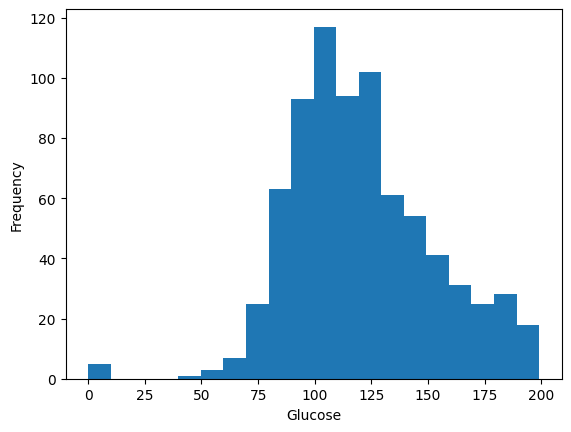

In [18]:
plt.hist(df['Glucose'],bins=20)
plt.xlabel('Glucose')
plt.ylabel('Frequency')


Text(0, 0.5, 'Glucose')

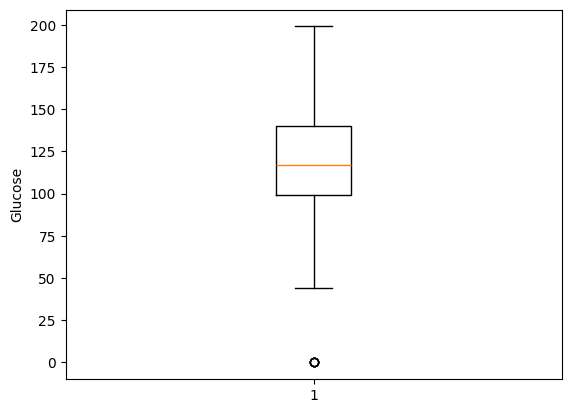

In [19]:
plt.boxplot(df['Glucose'])
plt.ylabel('Glucose')


In [20]:
x=100
y=140

In [21]:
mean=df['Glucose'].mean()
std=df['Glucose'].std()
print(mean)
print(std)


120.89453125
31.97261819513622


In [22]:
between =df[(df['Glucose']>=x)&(df['Glucose']<=y)]
print(between)
print(len(between))

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
4              0      137             40             35      168  43.1   
5              5      116             74              0        0  25.6   
7             10      115              0              0        0  35.3   
9              8      125             96              0        0   0.0   
10             4      110             92              0        0  37.6   
..           ...      ...            ...            ...      ...   ...   
758            1      106             76              0        0  37.5   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   

     DiabetesPedigreeFunction  Age  Outcome  Glucose_Z  
4                       2.288   33        1   0.504055

In [23]:
p_between=norm.cdf(y,mean,std)-norm.cdf(x,mean,std)
p_between

np.float64(0.46821958211558595)

In [26]:

up_to_x=df[df['Glucose']<=x]
print('up to ',x)
print('count = ',len(up_to_x))
print('percentage = ',len(up_to_x)/ len(df) * 100)


up to  100
count =  214
percentage =  27.864583333333332


In [27]:
#norm dist cdf
p_up_to_x = norm.cdf(x,mean,std)
print('normal probability = ',p_up_to_x)

normal probability =  0.256712708745466


In [28]:
# 3.people with glucose above x
above_x = df[df['Glucose']>x]
print('above ',x)
print('count = ',len(above_x))
print('percentage = ',len(above_x)/ len(df) * 100)


above  100
count =  554
percentage =  72.13541666666666


In [30]:
# 1-cdf
p_above_x = 1 - norm.cdf(x,mean,std)
print('normal probability = ',p_above_x)

normal probability =  0.7432872912545341


In [2]:
'''
exercise
read sachin_tendulkar.csv and calc the mean median minimum max and std of runs .plot hist of runs
'''
df = pd.read_csv('Sachin_Tendulkar.csv')
df

,Match_No,Innings,match_date,Versus,mode_of_dismissal,Runs,Balls_faced
0,1,1,1989-12-18 00:00:00,Pakistan,c Wasim Akram b Waqar Younis,0,2
1,2,2,1990-03-01 00:00:00,New Zealand,c & b S A Thomson,0,2
2,3,3,1990-03-06 00:00:00,New Zealand,c †I D S Smith b S A Thomson,36,39
3,4,4,1990-04-25 00:00:00,Sri Lanka,run out,10,12
4,5,5,1990-04-27 00:00:00,Pakistan,c Saeed Anwar b Imran Khan,20,25
...,...,...,...,...,...,...,...
447,459,448,2012-02-26 00:00:00,Australia,run out,14,15
448,460,449,2012-02-28 00:00:00,Sri Lanka,lbw b S L Malinga,39,30
449,461,450,2012-03-13 00:00:00,Sri Lanka,c D P M D Jayawardene b R A S Lakmal,6,19
450,462,451,2012-03-16 00:00:00,Bangladesh,c †Mushfiqur Rahim b Mashrafe Mortaza,114,147


 
mean = 40.76548672566372
median = 28.5
min = 0
max = 200
std = 40.0394800064396



Text(0, 0.5, 'count')

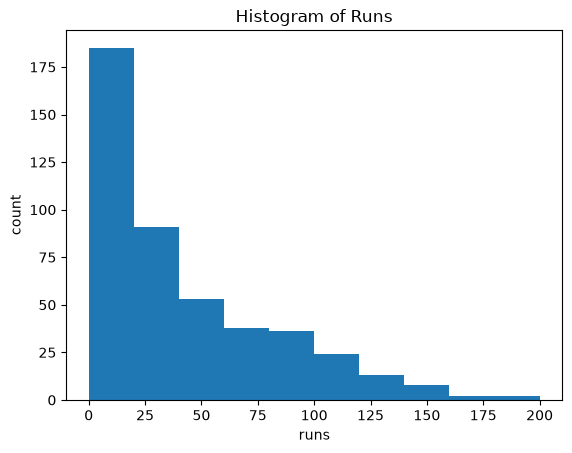

In [7]:
mean = df['Runs'].mean()
median = df['Runs'].median()
min = df['Runs'].min()
max = df['Runs'].max()
std = df['Runs'].std()

print(f''' 
mean = {mean}
median = {median}
min = {min}
max = {max}
std = {std}
''')

plt.hist(df['Runs'])
plt.title('Histogram of Runs')
plt.xlabel('runs')
plt.ylabel('count')

In [8]:
''' 
calculate z score of runs for everry innings. identify innings where |z| > 3. print no of outliers and display their runs and z scores

'''

' \ncalculate z score of runs for everry innings. identify innings where |z| > 3. print no of outliers and display their runs and z scores\n\n'

In [9]:
df['z-scores']=zscore(df['Runs'])
df

,Match_No,Innings,match_date,Versus,mode_of_dismissal,Runs,Balls_faced,z-scores
0,1,1,1989-12-18 00:00:00,Pakistan,c Wasim Akram b Waqar Younis,0,2,-1.019260
1,2,2,1990-03-01 00:00:00,New Zealand,c & b S A Thomson,0,2,-1.019260
2,3,3,1990-03-06 00:00:00,New Zealand,c †I D S Smith b S A Thomson,36,39,-0.119152
3,4,4,1990-04-25 00:00:00,Sri Lanka,run out,10,12,-0.769230
4,5,5,1990-04-27 00:00:00,Pakistan,c Saeed Anwar b Imran Khan,20,25,-0.519200
...,...,...,...,...,...,...,...,...
447,459,448,2012-02-26 00:00:00,Australia,run out,14,15,-0.669218
448,460,449,2012-02-28 00:00:00,Sri Lanka,lbw b S L Malinga,39,30,-0.044143
449,461,450,2012-03-13 00:00:00,Sri Lanka,c D P M D Jayawardene b R A S Lakmal,6,19,-0.869242
450,462,451,2012-03-16 00:00:00,Bangladesh,c †Mushfiqur Rahim b Mashrafe Mortaza,114,147,1.831084


In [13]:
df[df['z-scores'].abs() >3]

,Match_No,Innings,match_date,Versus,mode_of_dismissal,Runs,Balls_faced,z-scores
218,226,219,1999-11-08 00:00:00,New Zealand,not out,186,150,3.631302
414,425,415,2009-03-08 00:00:00,New Zealand,retired hurt,163,133,3.056232
423,435,424,2009-11-05 00:00:00,Australia,c N M Hauritz b C J McKay,175,141,3.356269
430,442,431,2010-02-24 00:00:00,South Africa,not out,200,147,3.981344


In [ ]:
''' 
3. plot histogram of runs using 20 bins and box plot of runs, identify unusally high scoring innings using box plot.

4.calc z -score for balls_faced identify inning where |z| >3 . display runs ,balls_faced and the z score for these inings

5.create a new col runs_per_ball = runs / balls_faced cal its mean and std. plot its hist and box plot identify outliers using z score

6. for x = 50  y =100 find the no and % of inning where runs  between x and y using normal distribution calc prob cdf(y) - cdf(x)

7. For x = 50 find the number and percentage of innings where Runs where up to x. Using a normal distribution, calculate the probability using CDF(x).


8. For x = 100 find the number and percentage of innings where Runs above x. Using a normal distribution, calculate the probability using 1 -  CDF(x).

9. Group the data by Versus and calculate the mean Runs against each team. Display the teams in descending order of average runs and plot a bar chart.

10. identify innings where runs > =100 , runs >= 50 and runs = 0,calc the no and percentage of innings in each category and plot a bar chart comparing the 3 categories.


    '''

' \n3. plot histogram of runs using 20 bins and box plot of runs, identify unusally high scoring innings using box plot.\n\n4.calc z -score for balls_faced identify inning where |z| >3 . display runs ,balls_faced and the z score for these inings\n\n5.create a new col runs_per_ball = runs / balls_faced cal its mean and std. plot its hist and box plot identify outliers using z score\n\n6. for x = 50  y =100 find the no and % of inning where runs  between x and y using normal distribution calc prob cdf(y) - cdf(x)\n\n7. For x = 50 find the number and percentage of innings where Runs where up to x. Using a normal distribution, calculate the probability using CDF(x).\n\n\n8. For x = 100 find the number and percentage of innings where Runs above x. Using a normal distribution, calculate the probability using 1 -  CDF(x).\n\n9. Group the data by Versus and calculate the mean Runs against each team. Display the teams in descending order of average runs and plot a bar chart.\n\n10. identify inn

(array([126.,  59.,  44.,  47.,  31.,  22.,  28.,  10.,  18.,  18.,  12.,
         12.,   9.,   4.,   7.,   1.,   1.,   1.,   1.,   1.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
        110., 120., 130., 140., 150., 160., 170., 180., 190., 200.]),
 <BarContainer object of 20 artists>)

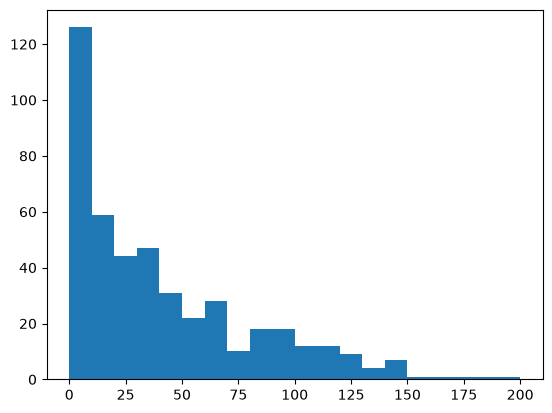

In [ ]:
#3.
plt.hist(df['Runs'],bins=20 )

{'whiskers': [<matplotlib.lines.Line2D at 0x244967c17f0>,
 'caps': [<matplotlib.lines.Line2D at 0x244967c1a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x244967c16a0>],
 'medians': [<matplotlib.lines.Line2D at 0x244967c1d30>],
 'fliers': [<matplotlib.lines.Line2D at 0x244967c1e80>],
 'means': []}

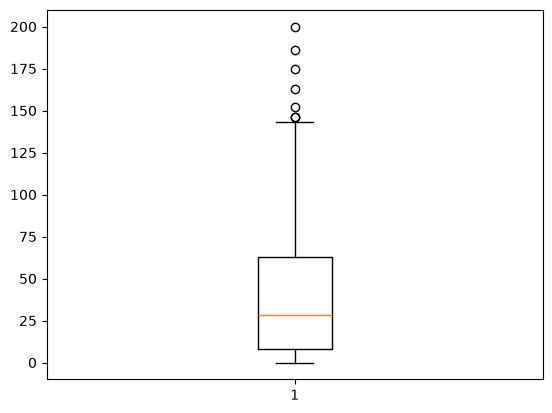

In [19]:
plt.boxplot(df['Runs'])


In [21]:
# 4.calc z -score for balls_faced identify inning where |z| >3 . display runs ,balls_faced and the z score for these inings

df['Balls_faced_z']=zscore(df['Balls_faced'])
df

,Match_No,Innings,match_date,Versus,mode_of_dismissal,Runs,Balls_faced,z-scores,Balls_faced_z
0,1,1,1989-12-18 00:00:00,Pakistan,c Wasim Akram b Waqar Younis,0,2,-1.019260,-1.132621
1,2,2,1990-03-01 00:00:00,New Zealand,c & b S A Thomson,0,2,-1.019260,-1.132621
2,3,3,1990-03-06 00:00:00,New Zealand,c †I D S Smith b S A Thomson,36,39,-0.119152,-0.206953
3,4,4,1990-04-25 00:00:00,Sri Lanka,run out,10,12,-0.769230,-0.882441
4,5,5,1990-04-27 00:00:00,Pakistan,c Saeed Anwar b Imran Khan,20,25,-0.519200,-0.557206
...,...,...,...,...,...,...,...,...,...
447,459,448,2012-02-26 00:00:00,Australia,run out,14,15,-0.669218,-0.807386
448,460,449,2012-02-28 00:00:00,Sri Lanka,lbw b S L Malinga,39,30,-0.044143,-0.432115
449,461,450,2012-03-13 00:00:00,Sri Lanka,c D P M D Jayawardene b R A S Lakmal,6,19,-0.869242,-0.707314
450,462,451,2012-03-16 00:00:00,Bangladesh,c †Mushfiqur Rahim b Mashrafe Mortaza,114,147,1.831084,2.494999


In [26]:
temp_df = df[df['Balls_faced_z'].abs() >=3 ]

print(temp_df)

Empty DataFrame
Columns: [Match_No, Innings, match_date, Versus, mode_of_dismissal, Runs, Balls_faced, z-scores, Balls_faced_z]
Index: []


In [28]:
df

,Match_No,Innings,match_date,Versus,mode_of_dismissal,Runs,Balls_faced,z-scores,Balls_faced_z
0,1,1,1989-12-18 00:00:00,Pakistan,c Wasim Akram b Waqar Younis,0,2,-1.019260,-1.132621
1,2,2,1990-03-01 00:00:00,New Zealand,c & b S A Thomson,0,2,-1.019260,-1.132621
2,3,3,1990-03-06 00:00:00,New Zealand,c †I D S Smith b S A Thomson,36,39,-0.119152,-0.206953
3,4,4,1990-04-25 00:00:00,Sri Lanka,run out,10,12,-0.769230,-0.882441
4,5,5,1990-04-27 00:00:00,Pakistan,c Saeed Anwar b Imran Khan,20,25,-0.519200,-0.557206
...,...,...,...,...,...,...,...,...,...
447,459,448,2012-02-26 00:00:00,Australia,run out,14,15,-0.669218,-0.807386
448,460,449,2012-02-28 00:00:00,Sri Lanka,lbw b S L Malinga,39,30,-0.044143,-0.432115
449,461,450,2012-03-13 00:00:00,Sri Lanka,c D P M D Jayawardene b R A S Lakmal,6,19,-0.869242,-0.707314
450,462,451,2012-03-16 00:00:00,Bangladesh,c †Mushfiqur Rahim b Mashrafe Mortaza,114,147,1.831084,2.494999


In [30]:
# 5.create a new col runs_per_ball = runs / balls_faced cal its mean and std. plot its hist and box plot identify outliers using z score

df['runs_per_ball'] = df['Runs'] / df['Balls_faced']
print(f'''  
mean = {df['runs_per_ball'].mean()}
std = {df['runs_per_ball'].std()}
 ''')

  
mean = 0.7458771106136745
std = 0.3590430487634779
 


In [ ]:
df['z-scores-runs-per-ball'] = zscore(df['runs_per_ball'])
df[df['z-scores-runs-per-ball'] > 3]    # outliers

,Match_No,Innings,match_date,Versus,mode_of_dismissal,Runs,Balls_faced,z-scores,Balls_faced_z,runs_per_ball,z-scores-runs-per-ball
372,383,373,2007-03-19 00:00:00,Bermuda,not out,57,29,0.405912,-0.457133,1.965517,3.400683


(array([ 40.,  34.,  61., 104., 105.,  62.,  31.,   8.,   6.,   1.]),
 array([0.        , 0.19655172, 0.39310345, 0.58965517, 0.7862069 ,
        0.98275862, 1.17931034, 1.37586207, 1.57241379, 1.76896552,
        1.96551724]),
 <BarContainer object of 10 artists>)

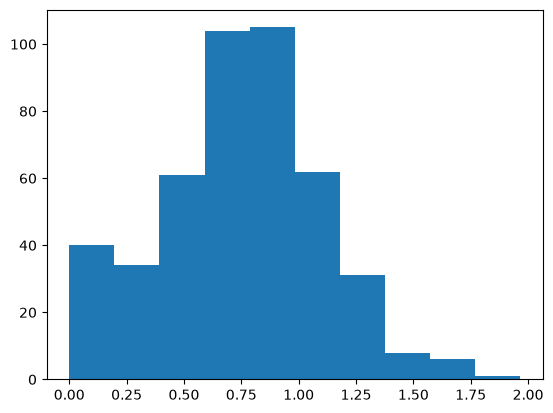

In [33]:
plt.hist(df['runs_per_ball'])

{'whiskers': [<matplotlib.lines.Line2D at 0x2449853e7b0>,
 'caps': [<matplotlib.lines.Line2D at 0x2449853ea50>,
 'boxes': [<matplotlib.lines.Line2D at 0x2449853e660>],
 'medians': [<matplotlib.lines.Line2D at 0x2449853ecf0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2449853ee40>],
 'means': []}

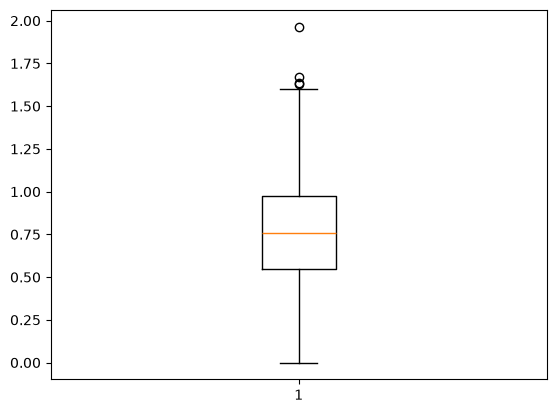

In [34]:
plt.boxplot(df['runs_per_ball'])

In [ ]:
# 6. for x = 50  y =100 find the no and % of inning where runs  between x and y using normal distribution calc prob cdf(y) - cdf(x)

x=50
y= 100
